# Wave and Earthquake PSD Inputs for Part 4.1

This notebook generates the dynamic inputs needed later in `JM_part_4.ipynb`:

- the **principal-horizontal bedrock seismic PSD** from `NL.G192..ALL.2018-01-08.dat`
- the **soil transfer function** from bedrock to ground surface
- the corresponding **surface acceleration and displacement PSDs**
- the **load-case-2 JONSWAP spectrum**
- the **Morison inertia-only wave-force PSD** for the submerged OWT segment
- an exported file `part41_input_psd.npz` with the arrays needed for part 4.1

The implementation reuses:

- the high-pass filtering and autocorrelation/FFT PSD idea from `PSD.ipynb`
- the JONSWAP formulation used in the wind-and-waves class exercises
- the Morison inertia term, with drag neglected as requested in the assignment

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.fft import rfft, rfftfreq
from scipy.signal import butter, correlate, filtfilt

plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True

In [2]:
# Student-ID digits and assignment values, matching Assignment.2.EQ.py
A, B, C, D, E, F, G = 6, 6, 1, 1, 2, 5, 7

student_digits = {"A": A, "B": B, "C": C, "D": D, "E": E, "F": F, "G": G}

M = (800 + 10 * F) * 1e3
J = 300e6
rho_t = 7850.0
E_t = 210e9
xi_t = 0.001
D_out_1 = 9.1
D_inner_1 = 8.96
D_out_2 = 7.1
D_inner_2 = 7.0
F_w = 2e5

H_t = 140 + A
H_w = 30 + F
H1 = 2 + B
H2 = 58 + G
H3 = 38 + F

G1 = (100 + 10 * F) * 1e6
rho1 = 1650.0
eta1 = 1000.0 + 10.0 * C

G2 = (100 + 10 * D) * 1e6
rho2 = 1850.0
eta2 = 1000.0 + 10.0 * E

G3 = (100 + 10 * E) * 1e6
rho3 = 1900.0
eta3 = 1000.0 + 10.0 * D

g = 9.81
rho_w = 1025.0
C_M = 2.0
gamma_jonswap = 3.3
U10_LC2 = 19.0
F_fetch = 180e3

Tp_LC2 = 0.286 * (g * F_fetch / U10_LC2**2) ** 0.33 * U10_LC2 / g
Hs_LC2 = 0.0016 * np.sqrt(g * F_fetch / U10_LC2**2) * U10_LC2**2 / g
omega_p_LC2 = 2 * np.pi / Tp_LC2

print("Student digits:", student_digits)
print(f"Tower height H_t = {H_t:.1f} m")
print(f"Water depth / submerged lower-segment height H_w = {H_w:.1f} m")
print(f"Soil layer thicknesses = ({H1:.1f}, {H2:.1f}, {H3:.1f}) m")
print(f"G = ({G1:.3e}, {G2:.3e}, {G3:.3e}) Pa")
print(f"rho = ({rho1:.1f}, {rho2:.1f}, {rho3:.1f}) kg/m^3")
print(f"eta = ({eta1:.1f}, {eta2:.1f}, {eta3:.1f}) Ns/m^2")
print(f"LC2 formulas: Tp = {Tp_LC2:.3f} s, Hs = {Hs_LC2:.3f} m, omega_p = {omega_p_LC2:.3f} rad/s")

Student digits: {'A': 6, 'B': 6, 'C': 1, 'D': 1, 'E': 2, 'F': 5, 'G': 7}
Tower height H_t = 146.0 m
Water depth / submerged lower-segment height H_w = 35.0 m
Soil layer thicknesses = (8.0, 65.0, 43.0) m
G = (1.500e+08, 1.100e+08, 1.200e+08) Pa
rho = (1650.0, 1850.0, 1900.0) kg/m^3
eta = (1010.0, 1020.0, 1010.0) Ns/m^2
LC2 formulas: Tp = 9.140 s, Hs = 4.118 m, omega_p = 0.687 rad/s


## Modelling Assumptions

The notebook makes the following explicit assumptions for part 4.1:

1. The **principal horizontal seismic component** is obtained by rotating the two filtered horizontal recordings to the direction of maximum variance.
2. The seismic PSD estimate follows the same idea as `PSD.ipynb`: high-pass filter first, then obtain the PSD from the Fourier transform of the autocorrelation function.
3. The soil transfer from bedrock to surface uses the **same three-layer SH-wave model** as before, now with the assignment damping coefficients \(\eta_1,\eta_2,\eta_3\). Stress continuity is enforced with the **complex shear modulus**
   \[
   G_i^\*(\omega) = G_i + i\omega\eta_i.
   \]
4. Because for harmonic motion the ratios \(U/U_g\) and \(a/a_g\) are identical, the soil transfer is solved with **unit bedrock displacement amplitude** \(U_g = 1\).
5. For the wave input, the submerged OWT segment is taken as the lower tower segment of height \(H_w\) and outer diameter \(D_{\mathrm{out},1}\).
6. Wave kinematics follow **linear Airy wave theory** in finite depth \(h = H_w\), and only the **Morison inertia term** is retained:
   \[
   q_I(y,\omega) = \rho_w C_M \frac{\pi D^2}{4} a_x(y,\omega).
   \]

In [3]:
def highpass_filter(signal, fs, cutoff=0.1, order=4):
    signal = np.asarray(signal, dtype=float)
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype="high", analog=False)
    return filtfilt(b, a, signal)


def principal_horizontal_component(accel_x, accel_y):
    horizontal = np.vstack([np.asarray(accel_x, dtype=float), np.asarray(accel_y, dtype=float)])
    covariance = np.cov(horizontal)
    eigvals, eigvecs = np.linalg.eigh(covariance)
    axis = eigvecs[:, np.argmax(eigvals)]
    principal = axis[0] * accel_x + axis[1] * accel_y

    # Fix the arbitrary sign so that the largest excursion is positive.
    if abs(np.min(principal)) > abs(np.max(principal)):
        principal = -principal
        axis = -axis

    return principal, axis, eigvals


def autocorrelation_psd_hz(signal, dt):
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)

    corr = correlate(signal, signal, mode="full") * dt
    N = signal.size
    lags = np.arange(-N + 1, N)
    normalization = (N - np.abs(lags)) * dt
    corr = corr / normalization

    psd = np.real(rfft(corr)) * dt
    psd = np.maximum(psd, 0.0)
    freq_hz = rfftfreq(corr.size, dt)
    return freq_hz, psd, corr


def hz_psd_to_omega(psd_hz):
    return np.asarray(psd_hz, dtype=float) / (2.0 * np.pi)


def omega_psd_to_hz(psd_omega):
    return np.asarray(psd_omega, dtype=float) * (2.0 * np.pi)


def jonswap_spectrum_hz(freq_hz, U10, fetch, gamma=3.3, g=9.81):
    freq_hz = np.asarray(freq_hz, dtype=float)
    spectrum = np.zeros_like(freq_hz)
    positive = freq_hz > 0.0

    F_tilde = g * fetch / U10**2
    f_tilde_p = 3.5 * F_tilde ** (-0.33)
    f_p = f_tilde_p * g / U10
    alpha = 0.076 * F_tilde ** (-0.22)

    sigma = np.where(freq_hz <= f_p, 0.07, 0.09)
    ratio = np.zeros_like(freq_hz)
    ratio[positive] = freq_hz[positive] / f_p
    peak_shape = np.exp(-0.5 * ((ratio - 1.0) / sigma) ** 2)

    spectrum[positive] = (
        alpha
        * g**2
        * (2.0 * np.pi) ** (-4)
        * freq_hz[positive] ** (-5)
        * np.exp(-1.25 * ratio[positive] ** (-4))
        * gamma ** peak_shape[positive]
    )
    return spectrum, f_p, alpha


def dispersion_wavenumber(omega, depth, g=9.81, tol=1e-12, max_iter=80):
    omega = float(omega)
    if omega == 0.0:
        return 0.0

    k = max(omega**2 / g, 1e-12)
    for _ in range(max_iter):
        kh = k * depth
        tanh_kh = np.tanh(kh)
        residual = g * k * tanh_kh - omega**2
        derivative = g * (tanh_kh + kh * (1.0 - tanh_kh**2))
        step = residual / derivative
        k_new = max(k - step, 1e-12)
        if abs(k_new - k) < tol * max(1.0, abs(k_new)):
            k = k_new
            break
        k = k_new
    return k


def depth_shape_factor(k, y, depth):
    y = np.asarray(y, dtype=float)
    kh = k * depth
    if kh < 40.0:
        return np.cosh(k * y) / np.sinh(kh)

    numerator = np.exp(-k * (depth - y)) * (1.0 + np.exp(-2.0 * k * y))
    denominator = 1.0 - np.exp(-2.0 * kh)
    return numerator / denominator

Seismic file: NL.G192..ALL.2018-01-08.dat
dt = 0.0050 s, fs = 200.00 Hz, duration = 131.11 s
Principal horizontal rotation angle from NS toward EW = 132.08 deg


Peak filtered principal acceleration = 0.034059 m/s^2


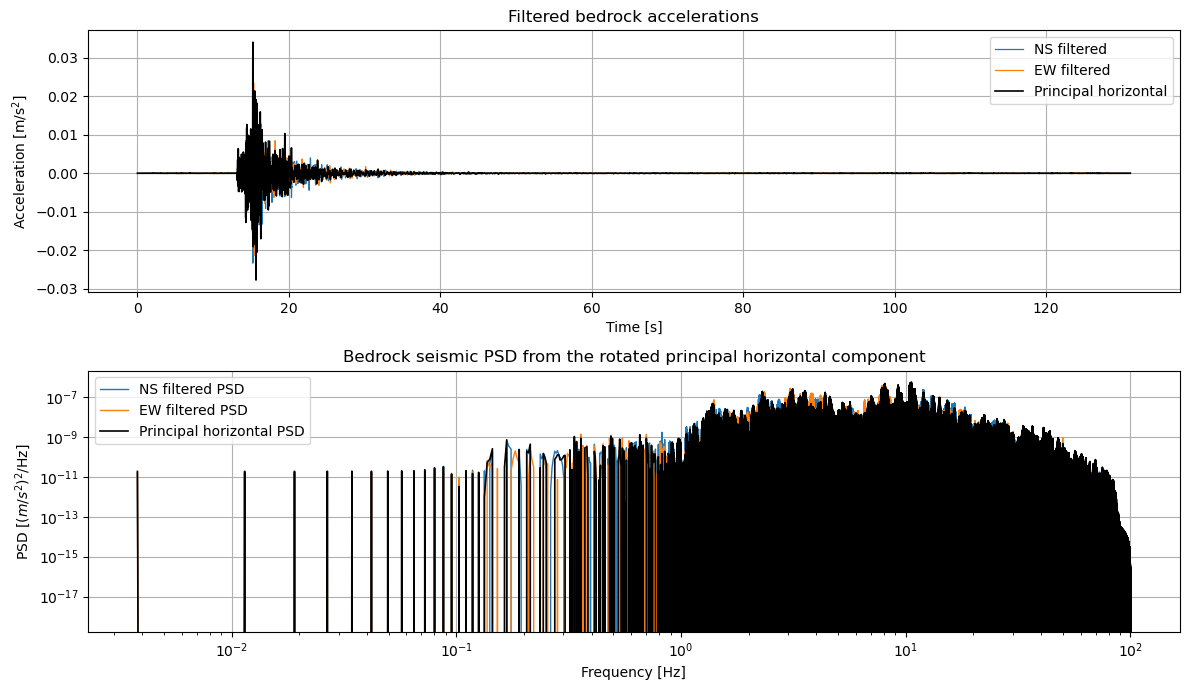

In [4]:
# Seismic input at bedrock level
seismic_file = Path("NL.G192..ALL.2018-01-08.dat")
data = np.loadtxt(seismic_file)

if data.shape[1] < 4:
    raise ValueError("Expected 4 columns: time, horizontal 1, horizontal 2, vertical.")

time = data[:, 0]
accel_ns = data[:, 1]
accel_ew = data[:, 2]
accel_vertical = data[:, 3]

dt = time[1] - time[0]
fs = 1.0 / dt
duration = time[-1] - time[0]

accel_ns_f = highpass_filter(accel_ns, fs, cutoff=0.1)
accel_ew_f = highpass_filter(accel_ew, fs, cutoff=0.1)
accel_vertical_f = highpass_filter(accel_vertical, fs, cutoff=0.1)

accel_principal, principal_axis, principal_eigvals = principal_horizontal_component(accel_ns_f, accel_ew_f)
principal_angle_deg = np.degrees(np.arctan2(principal_axis[1], principal_axis[0]))

freq_ns_hz, Sa_ns_hz, _ = autocorrelation_psd_hz(accel_ns_f, dt)
freq_ew_hz, Sa_ew_hz, _ = autocorrelation_psd_hz(accel_ew_f, dt)
freq_principal_raw_hz, Sa_principal_raw_hz, _ = autocorrelation_psd_hz(accel_principal, dt)

print(f"Seismic file: {seismic_file}")
print(f"dt = {dt:.4f} s, fs = {fs:.2f} Hz, duration = {duration:.2f} s")
print(f"Principal horizontal rotation angle from NS toward EW = {principal_angle_deg:.2f} deg")
print(f"Peak filtered principal acceleration = {np.max(np.abs(accel_principal)):.6f} m/s^2")

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)

axes[0].plot(time, accel_ns_f, label="NS filtered", lw=0.9)
axes[0].plot(time, accel_ew_f, label="EW filtered", lw=0.9)
axes[0].plot(time, accel_principal, label="Principal horizontal", lw=1.2, color="black")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Acceleration [m/s$^2$]")
axes[0].set_title("Filtered bedrock accelerations")
axes[0].legend()

axes[1].loglog(freq_ns_hz[1:], Sa_ns_hz[1:], label="NS filtered PSD", lw=1.0)
axes[1].loglog(freq_ew_hz[1:], Sa_ew_hz[1:], label="EW filtered PSD", lw=1.0)
axes[1].loglog(freq_principal_raw_hz[1:], Sa_principal_raw_hz[1:], label="Principal horizontal PSD", lw=1.2, color="black")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel(r"PSD [$(m/s^2)^2$/Hz]")
axes[1].set_title("Bedrock seismic PSD from the rotated principal horizontal component")
axes[1].legend()

plt.tight_layout()
plt.show()

Surface-transfer grid: 0.020 to 15.000 Hz with 4000 points
Maximum |H_soil(surface)| = 1958.229


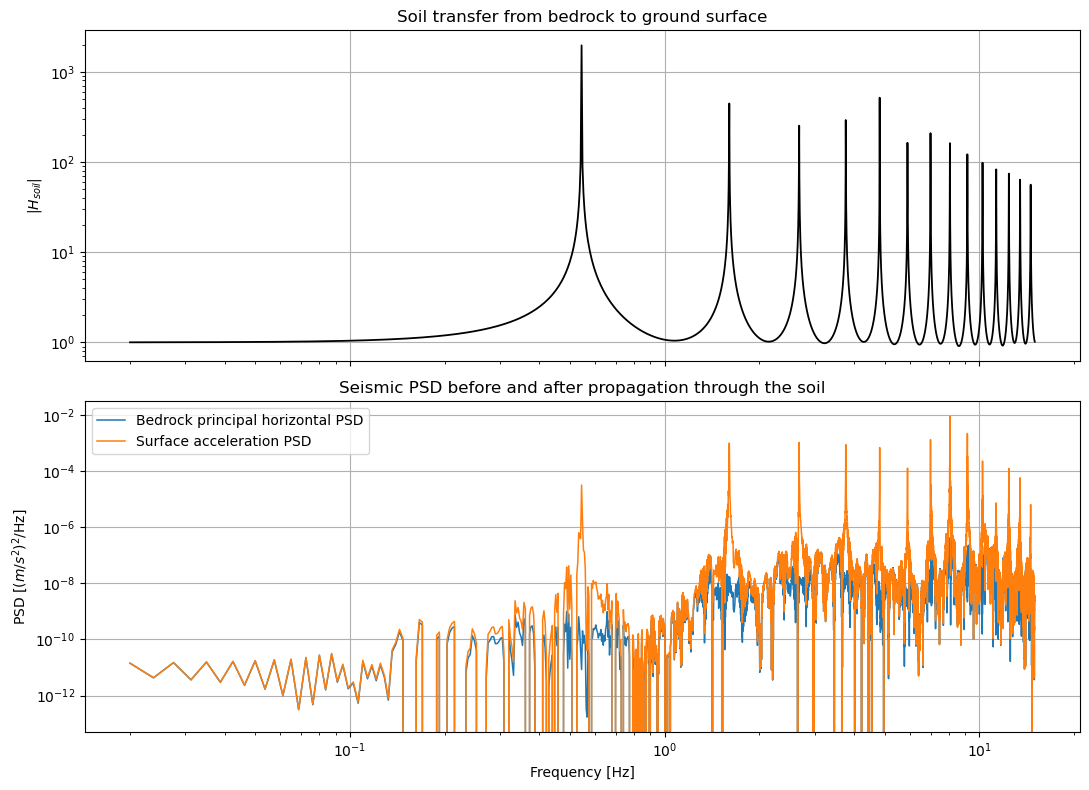

In [5]:
# Soil transfer from bedrock to surface
z0 = 0.0
z1 = -float(H1)
z2 = -float(H1 + H2)
z3 = -float(H1 + H2 + H3)


def complex_shear_modulus(G, eta, omega):
    return G + 1j * omega * eta


def soil_wavenumber(rho, G, eta, omega):
    G_star = complex_shear_modulus(G, eta, omega)
    return omega * np.sqrt(rho / G_star)


def basis_vector(k, z):
    return np.array([np.sin(k * z), np.cos(k * z)], dtype=complex)


def basis_gradient(k, z):
    return np.array([k * np.cos(k * z), -k * np.sin(k * z)], dtype=complex)


def build_soil_forced_system(omega, U_base=1.0):
    k1 = soil_wavenumber(rho1, G1, eta1, omega)
    k2 = soil_wavenumber(rho2, G2, eta2, omega)
    k3 = soil_wavenumber(rho3, G3, eta3, omega)

    G1_star = complex_shear_modulus(G1, eta1, omega)
    G2_star = complex_shear_modulus(G2, eta2, omega)
    G3_star = complex_shear_modulus(G3, eta3, omega)

    A = np.zeros((6, 6), dtype=complex)
    b = np.zeros(6, dtype=complex)

    # Constant order [C1, C2, C3, C4, C5, C6] = [layer 3, layer 2, layer 1]
    A[0, 4:6] = basis_gradient(k1, z0)

    A[1, 2:4] = -basis_vector(k2, z1)
    A[1, 4:6] = basis_vector(k1, z1)

    A[2, 2:4] = -G2_star * basis_gradient(k2, z1)
    A[2, 4:6] = G1_star * basis_gradient(k1, z1)

    A[3, 0:2] = -basis_vector(k3, z2)
    A[3, 2:4] = basis_vector(k2, z2)

    A[4, 0:2] = -G3_star * basis_gradient(k3, z2)
    A[4, 2:4] = G2_star * basis_gradient(k2, z2)

    A[5, 0:2] = basis_vector(k3, z3)
    b[5] = U_base

    return A, b


def solve_soil_constants(omega, U_base=1.0):
    A, b = build_soil_forced_system(omega, U_base=U_base)
    return np.linalg.solve(A, b)


def soil_surface_transfer(omega):
    C = solve_soil_constants(omega, U_base=1.0)
    U_surface = C[5]
    return U_surface


freq_principal_positive_hz = freq_principal_raw_hz[freq_principal_raw_hz > 0.0]
Sa_principal_positive_hz = Sa_principal_raw_hz[freq_principal_raw_hz > 0.0]

f_seismic_hz = np.linspace(0.02, 15.0, 4000)
omega_seismic = 2.0 * np.pi * f_seismic_hz

Sa_bedrock_hz = np.interp(f_seismic_hz, freq_principal_positive_hz, Sa_principal_positive_hz, left=0.0, right=0.0)
H_soil_surface = np.array([soil_surface_transfer(omega) for omega in omega_seismic], dtype=complex)

# For harmonic motion H = U/U_g = a/a_g, so the same transfer multiplies the acceleration PSD.
Sa_surface_hz = np.abs(H_soil_surface) ** 2 * Sa_bedrock_hz
Su_bedrock_hz = Sa_bedrock_hz / omega_seismic**4
Su_surface_hz = Sa_surface_hz / omega_seismic**4

Sa_bedrock_omega = hz_psd_to_omega(Sa_bedrock_hz)
Sa_surface_omega = hz_psd_to_omega(Sa_surface_hz)
Su_bedrock_omega = hz_psd_to_omega(Su_bedrock_hz)
Su_surface_omega = hz_psd_to_omega(Su_surface_hz)

print(f"Surface-transfer grid: {f_seismic_hz[0]:.3f} to {f_seismic_hz[-1]:.3f} Hz with {f_seismic_hz.size} points")
print(f"Maximum |H_soil(surface)| = {np.max(np.abs(H_soil_surface)):.3f}")

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].loglog(f_seismic_hz, np.abs(H_soil_surface), color="black", lw=1.3)
axes[0].set_ylabel(r"$|H_{soil}|$")
axes[0].set_title("Soil transfer from bedrock to ground surface")

axes[1].loglog(f_seismic_hz, Sa_bedrock_hz, label="Bedrock principal horizontal PSD", lw=1.1)
axes[1].loglog(f_seismic_hz, Sa_surface_hz, label="Surface acceleration PSD", lw=1.1)
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel(r"PSD [$(m/s^2)^2$/Hz]")
axes[1].set_title("Seismic PSD before and after propagation through the soil")
axes[1].legend()

plt.tight_layout()
plt.show()

## Wave Input from Load Case 2

The wave part follows the assignment instruction to use the **JONSWAP spectrum** from unit 2 and the **Morison inertia term** with drag neglected.

For later use in part 4.1, the notebook exports both:

- the **distributed force transfer** along the submerged segment
- convenient reduced quantities:
  - the **resultant horizontal wave-force PSD**
  - the **equivalent mudline overturning-moment PSD**

JONSWAP alpha = 0.01173
Spectral peak frequency from the JONSWAP array = 0.1095 Hz
Peak period from the JONSWAP array = 9.130 s
Integrated Hs from the JONSWAP array = 4.956 m


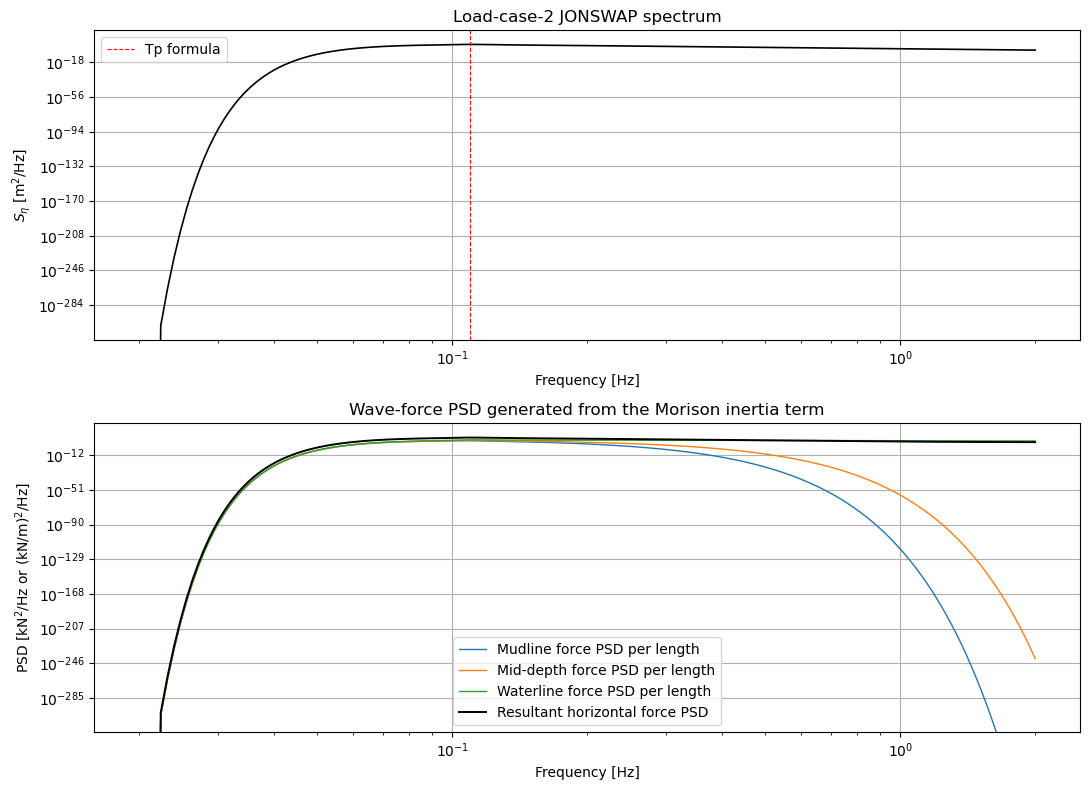

In [6]:
f_wave_hz = np.linspace(0.02, 2.0, 2500)
omega_wave = 2.0 * np.pi * f_wave_hz

S_eta_hz, f_p_spectrum_hz, alpha_jonswap = jonswap_spectrum_hz(
    f_wave_hz,
    U10=U10_LC2,
    fetch=F_fetch,
    gamma=gamma_jonswap,
    g=g,
)

Hs_from_integral = 4.0 * np.sqrt(np.trapezoid(S_eta_hz, f_wave_hz))
peak_index = int(np.argmax(S_eta_hz))
Tp_from_peak = 1.0 / f_wave_hz[peak_index]

wave_y = np.linspace(0.0, H_w, 81)  # 0 at mudline, H_w at still water level
wave_force_coeff = 0.25 * np.pi * rho_w * C_M * D_out_1**2

H_eta_to_q = np.zeros((f_wave_hz.size, wave_y.size), dtype=complex)
H_eta_to_resultant_force = np.zeros(f_wave_hz.size, dtype=complex)
H_eta_to_mudline_moment = np.zeros(f_wave_hz.size, dtype=complex)

for i, omega in enumerate(omega_wave):
    k = dispersion_wavenumber(omega, H_w, g=g)
    shape = depth_shape_factor(k, wave_y, H_w)
    accel_transfer = omega**2 * shape
    q_transfer = wave_force_coeff * accel_transfer

    H_eta_to_q[i, :] = q_transfer
    H_eta_to_resultant_force[i] = np.trapezoid(q_transfer, wave_y)
    H_eta_to_mudline_moment[i] = np.trapezoid(q_transfer * wave_y, wave_y)

S_eta_omega = hz_psd_to_omega(S_eta_hz)
S_q_hz = (np.abs(H_eta_to_q) ** 2) * S_eta_hz[:, None]
S_q_omega = hz_psd_to_omega(S_q_hz)

S_wave_resultant_force_hz = (np.abs(H_eta_to_resultant_force) ** 2) * S_eta_hz
S_wave_resultant_force_omega = hz_psd_to_omega(S_wave_resultant_force_hz)

S_wave_mudline_moment_hz = (np.abs(H_eta_to_mudline_moment) ** 2) * S_eta_hz
S_wave_mudline_moment_omega = hz_psd_to_omega(S_wave_mudline_moment_hz)

print(f"JONSWAP alpha = {alpha_jonswap:.5f}")
print(f"Spectral peak frequency from the JONSWAP array = {f_wave_hz[peak_index]:.4f} Hz")
print(f"Peak period from the JONSWAP array = {Tp_from_peak:.3f} s")
print(f"Integrated Hs from the JONSWAP array = {Hs_from_integral:.3f} m")

mid_index = wave_y.size // 2

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=False)

axes[0].loglog(f_wave_hz, S_eta_hz, color="black", lw=1.2)
axes[0].axvline(1.0 / Tp_LC2, color="red", ls="--", lw=0.8, label="Tp formula")
axes[0].set_xlabel("Frequency [Hz]")
axes[0].set_ylabel(r"$S_\eta$ [m$^2$/Hz]")
axes[0].set_title("Load-case-2 JONSWAP spectrum")
axes[0].legend()

axes[1].loglog(f_wave_hz, S_q_hz[:, 0] / 1e6, label="Mudline force PSD per length", lw=1.0)
axes[1].loglog(f_wave_hz, S_q_hz[:, mid_index] / 1e6, label="Mid-depth force PSD per length", lw=1.0)
axes[1].loglog(f_wave_hz, S_q_hz[:, -1] / 1e6, label="Waterline force PSD per length", lw=1.0)
axes[1].loglog(f_wave_hz, S_wave_resultant_force_hz / 1e6, label="Resultant horizontal force PSD", lw=1.4, color="black")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel(r"PSD [kN$^2$/Hz or (kN/m)$^2$/Hz]")
axes[1].set_title("Wave-force PSD generated from the Morison inertia term")
axes[1].legend()

plt.tight_layout()
plt.show()

In [7]:
# Export the input arrays for later use in JM_part_4.ipynb
output_file = Path("part41_input_psd.npz")

np.savez(
    output_file,
    student_digits=np.array([A, B, C, D, E, F, G], dtype=int),
    seismic_file=str(seismic_file),
    principal_axis=principal_axis,
    principal_angle_deg=np.array(principal_angle_deg, dtype=float),
    dt_seismic=np.array(dt, dtype=float),
    fs_seismic=np.array(fs, dtype=float),
    duration_seismic=np.array(duration, dtype=float),
    freq_principal_raw_hz=freq_principal_raw_hz,
    seismic_principal_bedrock_psd_raw_hz=Sa_principal_raw_hz,
    f_seismic_hz=f_seismic_hz,
    omega_seismic=omega_seismic,
    seismic_bedrock_accel_psd_hz=Sa_bedrock_hz,
    seismic_bedrock_accel_psd_omega=Sa_bedrock_omega,
    soil_surface_transfer_complex=H_soil_surface,
    seismic_surface_accel_psd_hz=Sa_surface_hz,
    seismic_surface_accel_psd_omega=Sa_surface_omega,
    seismic_bedrock_disp_psd_hz=Su_bedrock_hz,
    seismic_bedrock_disp_psd_omega=Su_bedrock_omega,
    seismic_surface_disp_psd_hz=Su_surface_hz,
    seismic_surface_disp_psd_omega=Su_surface_omega,
    f_wave_hz=f_wave_hz,
    omega_wave=omega_wave,
    wave_y_from_mudline=wave_y,
    jonswap_surface_elevation_psd_hz=S_eta_hz,
    jonswap_surface_elevation_psd_omega=S_eta_omega,
    wave_force_transfer_per_length=H_eta_to_q,
    wave_force_psd_per_length_hz=S_q_hz,
    wave_force_psd_per_length_omega=S_q_omega,
    wave_resultant_force_transfer=H_eta_to_resultant_force,
    wave_resultant_force_psd_hz=S_wave_resultant_force_hz,
    wave_resultant_force_psd_omega=S_wave_resultant_force_omega,
    wave_mudline_moment_transfer=H_eta_to_mudline_moment,
    wave_mudline_moment_psd_hz=S_wave_mudline_moment_hz,
    wave_mudline_moment_psd_omega=S_wave_mudline_moment_omega,
    H_w=np.array(H_w, dtype=float),
    D_wave=np.array(D_out_1, dtype=float),
    C_M=np.array(C_M, dtype=float),
    rho_w=np.array(rho_w, dtype=float),
)

print(f"Saved {output_file} with the part 4.1 input arrays.")
print("\nMost direct arrays for the next notebook:")
print("  seismic_surface_disp_psd_omega")
print("  soil_surface_transfer_complex")
print("  wave_force_transfer_per_length")
print("  wave_resultant_force_psd_omega")
print("  wave_mudline_moment_psd_omega")

Saved part41_input_psd.npz with the part 4.1 input arrays.

Most direct arrays for the next notebook:
  seismic_surface_disp_psd_omega
  soil_surface_transfer_complex
  wave_force_transfer_per_length
  wave_resultant_force_psd_omega
  wave_mudline_moment_psd_omega
